# **Line Charts**

In this lab, you will focus on using line charts to analyze trends over time and across different categories in a dataset.

## Objectives

In this lab you will perform the following:

- Track trends in compensation across age groups and specific age ranges.

- Analyze job satisfaction trends based on experience level.

- Explore and interpret line charts to identify patterns and trends.

## Setup: Working with the Database
**Install the needed libraries**

In [1]:
#!pip install pandas
#!pip install matplotlib

**Download and connect to the database file containing survey data.**

To start, download and load the dataset into a `pandas` DataFrame.

#### Step 1: Download the dataset

In [2]:
# If wget does not work on Windows/Jupyter,
# directly load the dataset from the URL

import pandas as pd
import matplotlib.pyplot as plt

# Dataset URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load dataset
df = pd.read_csv(file_url)

# Display first few rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


#### Step 2: Import necessary libraries and load the dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

#### Load the data

In [4]:
df = pd.read_csv(file_url)

#### Display the first few rows to understand the structure of the data

In [5]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Trends in Compensation Over Age Groups

##### 1. Line Chart of Median `ConvertedCompYearly` by Age Group

- Track how the median yearly compensation (ConvertedCompYearly) changes across different age groups.

- Use a line chart to visualize these trends.

In [6]:
# Select required columns

comp_df = df[['Age', 'ConvertedCompYearly']].dropna()

# Convert compensation to numeric

comp_df['ConvertedCompYearly'] = pd.to_numeric(
    comp_df['ConvertedCompYearly'],
    errors='coerce'
)

comp_df = comp_df.dropna()

In [7]:
# Calculate median compensation by age group

median_comp = (
    comp_df
    .groupby('Age')['ConvertedCompYearly']
    .median()
    .reset_index()
)

print(median_comp)

                  Age  ConvertedCompYearly
0     18-24 years old              25000.0
1     25-34 years old              59825.0
2     35-44 years old              84796.0
3     45-54 years old              99099.0
4     55-64 years old             109691.0
5   65 years or older             106000.0
6   Prefer not to say             140000.0
7  Under 18 years old               7626.5


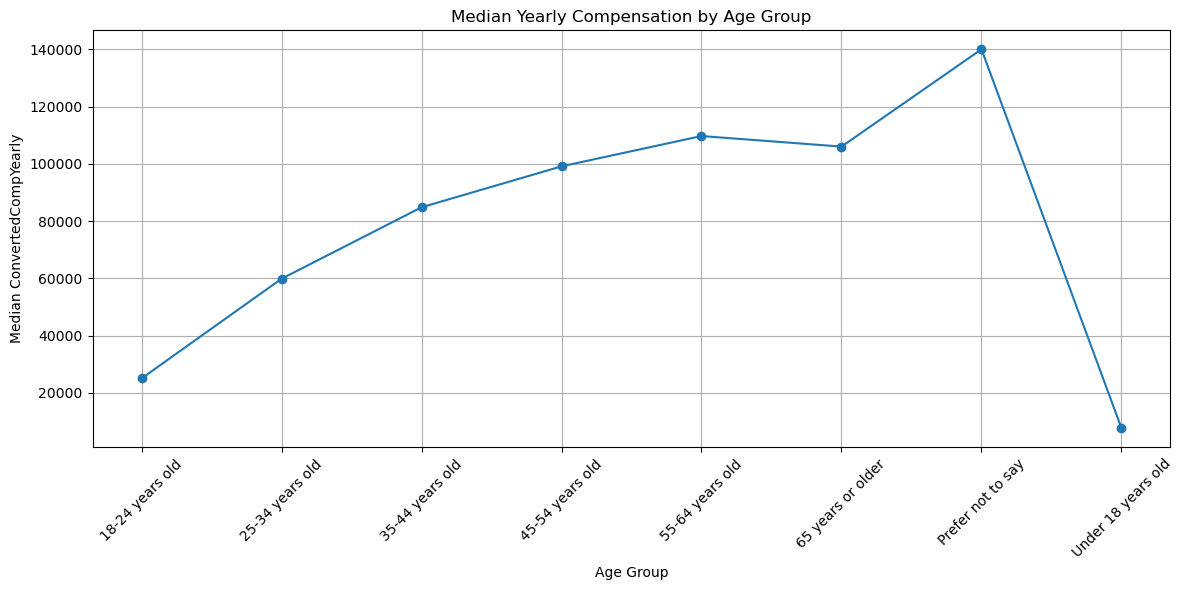

In [8]:
# Create line chart

plt.figure(figsize=(12,6))

plt.plot(
    median_comp['Age'],
    median_comp['ConvertedCompYearly'],
    marker='o'
)

plt.title('Median Yearly Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median ConvertedCompYearly')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

##### 2. Line Chart of Median `ConvertedCompYearly` for Ages 25 to 45

For a closer look, plot a line chart focusing on the median compensation for respondents between ages 25 and 45.

In [9]:
# Select required columns

comp_df = df[['Age', 'ConvertedCompYearly']].dropna()

# Convert compensation to numeric

comp_df['ConvertedCompYearly'] = pd.to_numeric(
    comp_df['ConvertedCompYearly'],
    errors='coerce'
)

comp_df = comp_df.dropna()

In [10]:
# Keep only respondents aged 25 to 45
# Assuming Age contains age groups such as:
# '25-34 years old' and '35-44 years old'

target_ages = [
    '25-34 years old',
    '35-44 years old'
]

filtered_df = comp_df[
    comp_df['Age'].isin(target_ages)
]

In [11]:
# Calculate median compensation by age group

median_comp = (
    filtered_df
    .groupby('Age')['ConvertedCompYearly']
    .median()
    .reset_index()
)

print(median_comp)

               Age  ConvertedCompYearly
0  25-34 years old              59825.0
1  35-44 years old              84796.0


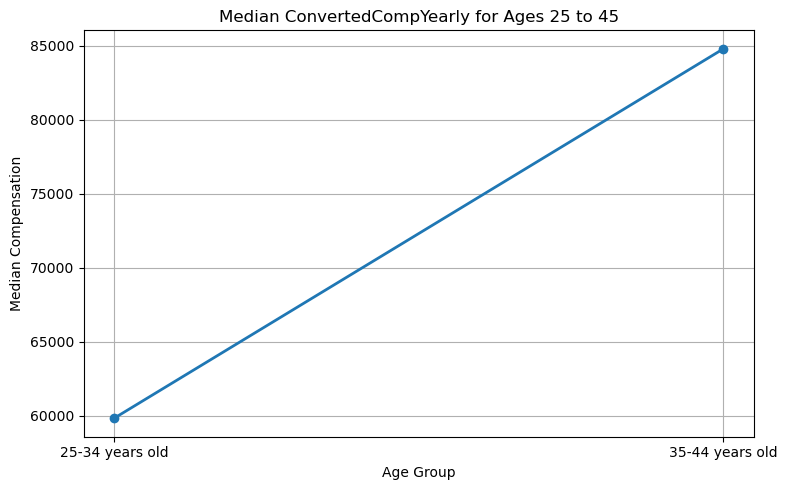

In [12]:
# Plot line chart

plt.figure(figsize=(8,5))

plt.plot(
    median_comp['Age'],
    median_comp['ConvertedCompYearly'],
    marker='o',
    linewidth=2
)

plt.title('Median ConvertedCompYearly for Ages 25 to 45')
plt.xlabel('Age Group')
plt.ylabel('Median Compensation')

plt.grid(True)

plt.tight_layout()
plt.show()

### Task 2: Trends in Job Satisfaction by Experience Level

##### 1. Line Chart of Job Satisfaction (`JobSatPoints_6`) by Experience Level

- Use a column that approximates experience level to analyze how job satisfaction changes with experience.

- If needed, substitute an available experience-related column for `Experience`.

In [13]:
# Select required columns

exp_df = df[
    ['YearsCodePro', 'JobSatPoints_6']
].dropna()

# Display first few rows
print(exp_df.head())

        YearsCodePro  JobSatPoints_6
1                 17             0.0
12                12            30.0
15                27             0.0
18                10            60.0
20  Less than 1 year           100.0


In [14]:
# Convert JobSatPoints_6 to numeric

exp_df['JobSatPoints_6'] = pd.to_numeric(
    exp_df['JobSatPoints_6'],
    errors='coerce'
)

# Convert YearsCodePro to numeric
# Remove non-numeric values such as "Less than 1 year" or "More than 50 years"

exp_df['YearsCodePro'] = pd.to_numeric(
    exp_df['YearsCodePro'],
    errors='coerce'
)

exp_df = exp_df.dropna()

In [15]:
# Calculate median job satisfaction by experience level

jobsat_by_exp = (
    exp_df
    .groupby('YearsCodePro')['JobSatPoints_6']
    .median()
    .reset_index()
    .sort_values('YearsCodePro')
)

print(jobsat_by_exp.head())

   YearsCodePro  JobSatPoints_6
0           1.0            15.0
1           2.0            15.0
2           3.0            20.0
3           4.0            20.0
4           5.0            20.0


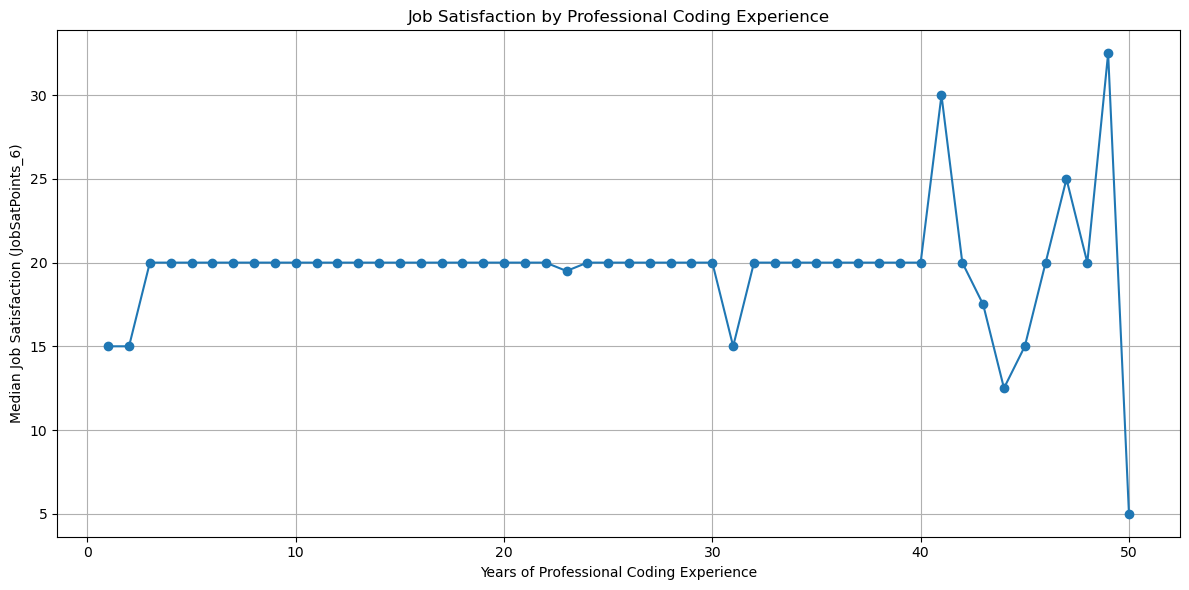

In [16]:
# Create line chart

plt.figure(figsize=(12,6))

plt.plot(
    jobsat_by_exp['YearsCodePro'],
    jobsat_by_exp['JobSatPoints_6'],
    marker='o'
)

plt.title('Job Satisfaction by Professional Coding Experience')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Median Job Satisfaction (JobSatPoints_6)')

plt.grid(True)

plt.tight_layout()
plt.show()

### Task 3: Trends in Job Satisfaction and Compensation by Experience

##### 1.Line Chart of Median ConvertedCompYearly Over Experience Level

- This line chart will track how median compensation (`ConvertedCompYearly`) changes with increasing experience.

- Use a column such as `WorkExp` or another relevant experience-related column.

In [17]:
# Select required columns

comp_exp_df = df[
    ['WorkExp', 'ConvertedCompYearly']
].dropna()

# Display first few rows
print(comp_exp_df.head())

     WorkExp  ConvertedCompYearly
72       3.0               7322.0
379      7.0              91295.0
389      8.0             110000.0
392     18.0             161044.0
398     30.0             195000.0


In [18]:
# Convert columns to numeric

comp_exp_df['WorkExp'] = pd.to_numeric(
    comp_exp_df['WorkExp'],
    errors='coerce'
)

comp_exp_df['ConvertedCompYearly'] = pd.to_numeric(
    comp_exp_df['ConvertedCompYearly'],
    errors='coerce'
)

comp_exp_df = comp_exp_df.dropna()

In [19]:
# Calculate median compensation by experience level

median_comp_exp = (
    comp_exp_df
    .groupby('WorkExp')['ConvertedCompYearly']
    .median()
    .reset_index()
    .sort_values('WorkExp')
)

print(median_comp_exp.head())

   WorkExp  ConvertedCompYearly
0      0.0              13306.0
1      1.0              20077.0
2      2.0              27968.5
3      3.0              34896.0
4      4.0              42962.0


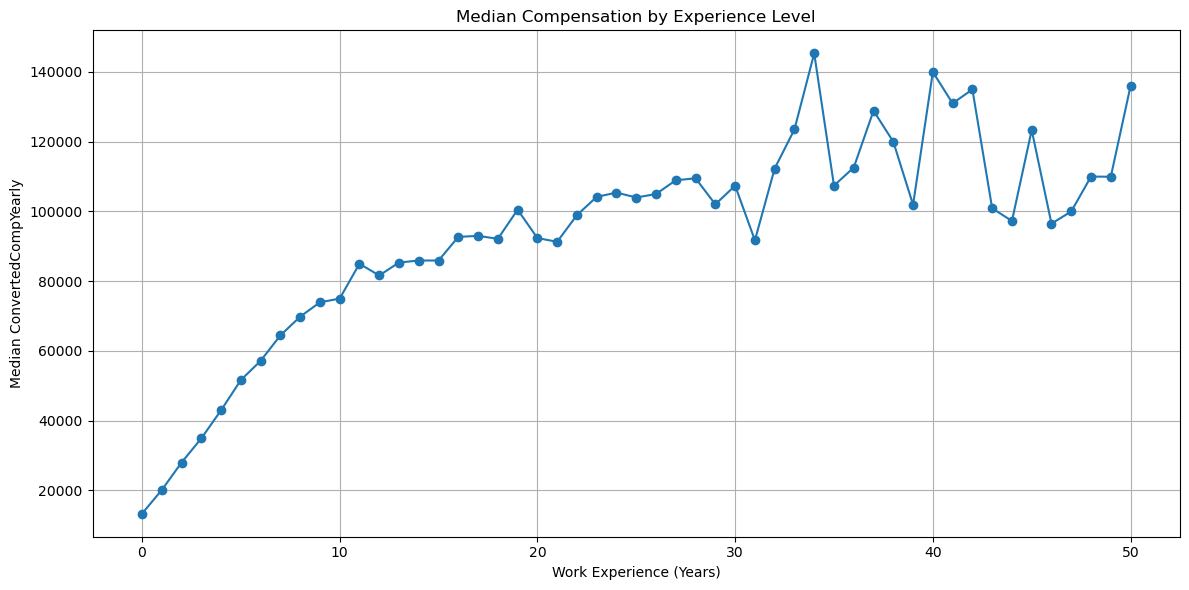

In [20]:
# Plot line chart

plt.figure(figsize=(12,6))

plt.plot(
    median_comp_exp['WorkExp'],
    median_comp_exp['ConvertedCompYearly'],
    marker='o'
)

plt.title('Median Compensation by Experience Level')
plt.xlabel('Work Experience (Years)')
plt.ylabel('Median ConvertedCompYearly')

plt.grid(True)

plt.tight_layout()
plt.show()

##### 2.Line Chart of Job Satisfaction (`JobSatPoints_6`) Across Experience Levels

- Create a line chart to explore trends in job satisfaction (`JobSatPoints_6`) based on experience level.

- This chart will provide insight into how satisfaction correlates with experience over time

In [21]:
# Select required columns

jobsat_df = df[
    ['WorkExp', 'JobSatPoints_6']
].dropna()

# Display first few rows
print(jobsat_df.head())

    WorkExp  JobSatPoints_6
1      17.0             0.0
10     15.0            25.0
12     12.0            30.0
15     29.0             0.0
18     12.0            60.0


In [22]:
# Convert columns to numeric

jobsat_df['WorkExp'] = pd.to_numeric(
    jobsat_df['WorkExp'],
    errors='coerce'
)

jobsat_df['JobSatPoints_6'] = pd.to_numeric(
    jobsat_df['JobSatPoints_6'],
    errors='coerce'
)

jobsat_df = jobsat_df.dropna()

In [23]:
# Calculate median job satisfaction by experience level

jobsat_trend = (
    jobsat_df
    .groupby('WorkExp')['JobSatPoints_6']
    .median()
    .reset_index()
    .sort_values('WorkExp')
)

print(jobsat_trend.head())

   WorkExp  JobSatPoints_6
0      0.0             5.0
1      1.0            10.0
2      2.0            15.0
3      3.0            20.0
4      4.0            20.0


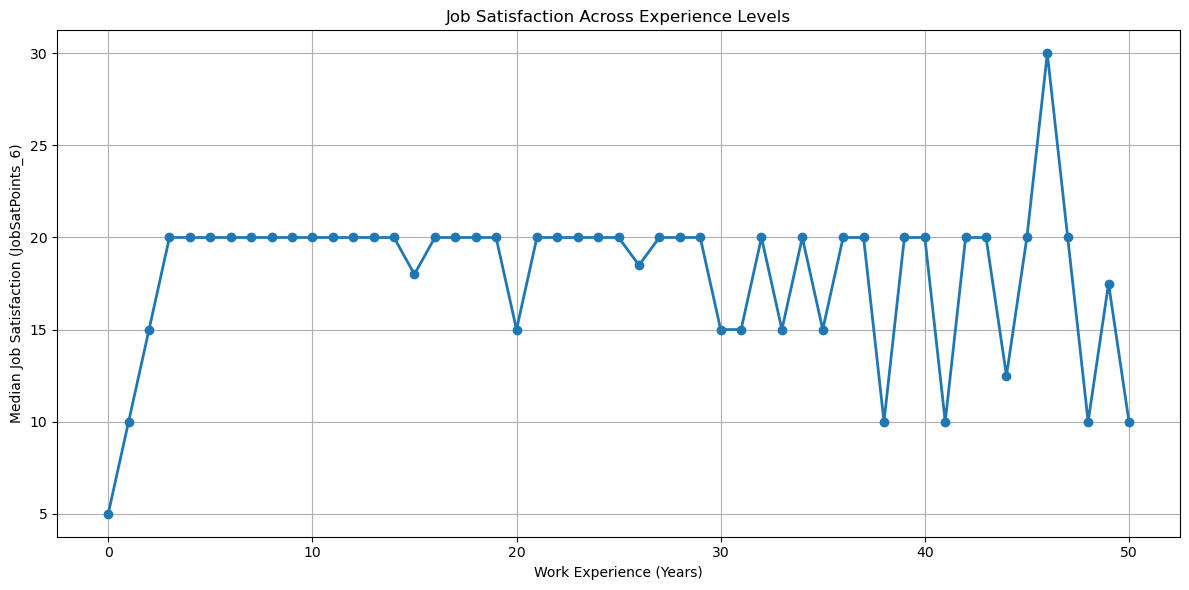

In [24]:
# Create line chart

plt.figure(figsize=(12,6))

plt.plot(
    jobsat_trend['WorkExp'],
    jobsat_trend['JobSatPoints_6'],
    marker='o',
    linewidth=2
)

plt.title('Job Satisfaction Across Experience Levels')
plt.xlabel('Work Experience (Years)')
plt.ylabel('Median Job Satisfaction (JobSatPoints_6)')

plt.grid(True)

plt.tight_layout()
plt.show()

#### Final Step: Review

In this lab, you focused on analyzing trends in compensation and job satisfaction, specifically exploring how these metrics change with age and experience levels using line charts.

### Summary

In this lab, you explored essential data visualization techniques with a focus on analyzing trends using line charts. You learned to:

- Visualize the distribution of compensation across age groups to understand salary trends.

- Track changes in median compensation over various experience levels, identifying how earnings progress with experience.

- Examine trends in job satisfaction by experience, revealing how satisfaction varies throughout a developer's career.

These analyses allow for a deeper understanding of how factors like age and experience influence job satisfaction and compensation. By using line charts, you gained insights into continuous data patterns, which are invaluable for interpreting professional trends in the developer community.